In [28]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install kagglehub
!pip install scikit-learn

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Set plot style
sns.set_style('whitegrid')

In [30]:
# Download the dataset using the Kaggle Hub API
print("Downloading dataset...")
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

# Load the dataset from the downloaded path
file_path = f'{path}/heart_disease_uci.csv'
df = pd.read_csv(file_path)

print("Dataset downloaded and loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()

Dataset downloaded and loaded successfully.
Data shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [31]:
# Initial inspection
print("Dataset Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isna().sum().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Descriptive Statistics:
               id         age    trestbps        chol      thalch     oldpeak  \
co

In [32]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [33]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 8 numerical features : ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']

We have 8 categorical features : ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [34]:
df.head(2)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2


In [35]:
# fill missing values in numerical features
for feature in numeric_features:
    df[feature].fillna(df[feature].median(), inplace=True)


/var/folders/lz/qs53dcdj7jd9mf40vp_hwblc0000gn/T/ipykernel_36667/4088130604.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feature].fillna(df[feature].median(), inplace=True)
/var/folders/lz/qs53dcdj7jd9mf40vp_hwblc0000gn/T/ipykernel_36667/4088130604.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [36]:
# fill missing values in categorical features
for feature in categorical_features:
    df[feature].fillna(df[feature].mode()[0], inplace=True)


/var/folders/lz/qs53dcdj7jd9mf40vp_hwblc0000gn/T/ipykernel_36667/1345865922.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feature].fillna(df[feature].mode()[0], inplace=True)
/var/folders/lz/qs53dcdj7jd9mf40vp_hwblc0000gn/T/ipykernel_36667/1345865922.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  

In [37]:
df.isnull().sum()


id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

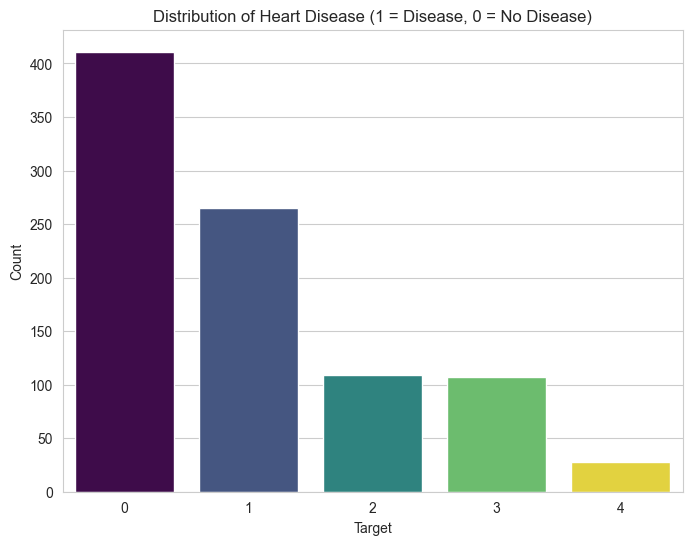

In [38]:
plt.figure(figsize=(8, 6))
sns.countplot(x='num', data=df, palette='viridis', hue='num', legend=False)
plt.title('Distribution of Heart Disease (1 = Disease, 0 = No Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

In [39]:
num_cols = df.select_dtypes(exclude='object').columns


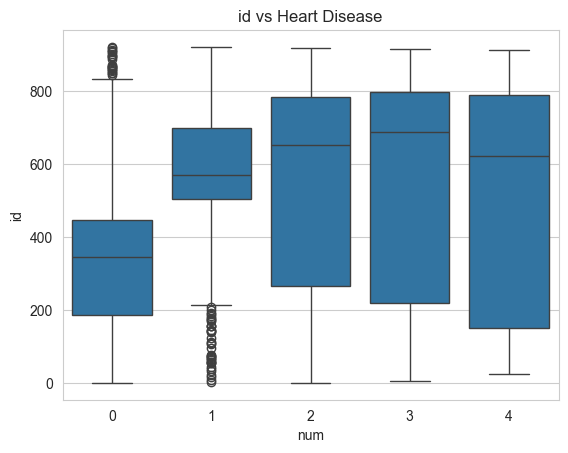

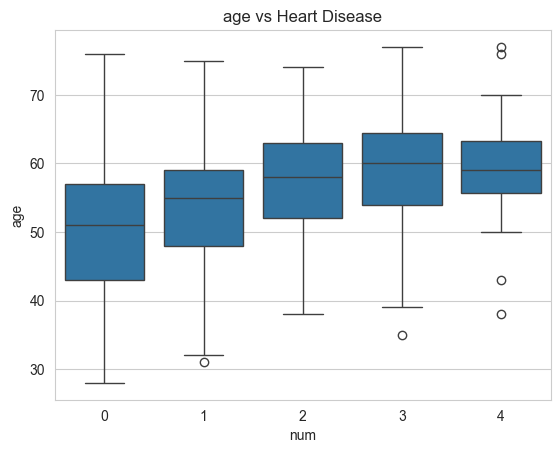

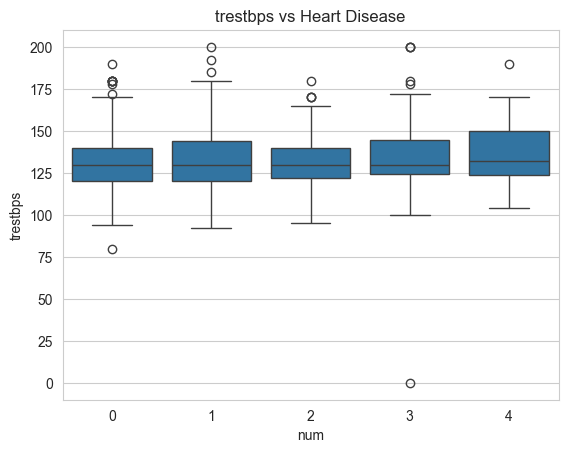

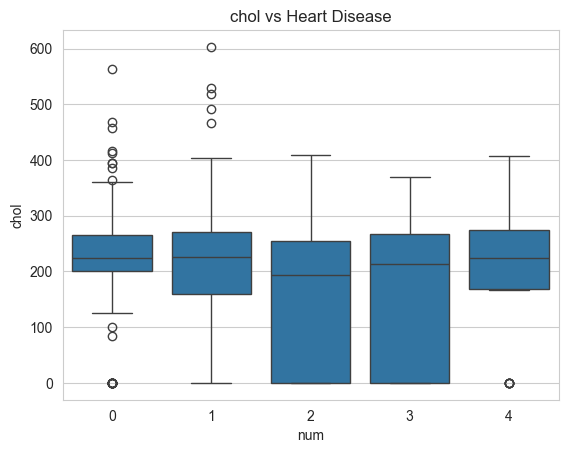

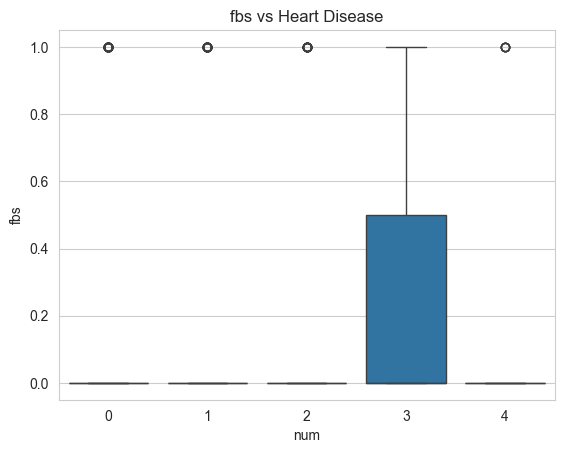

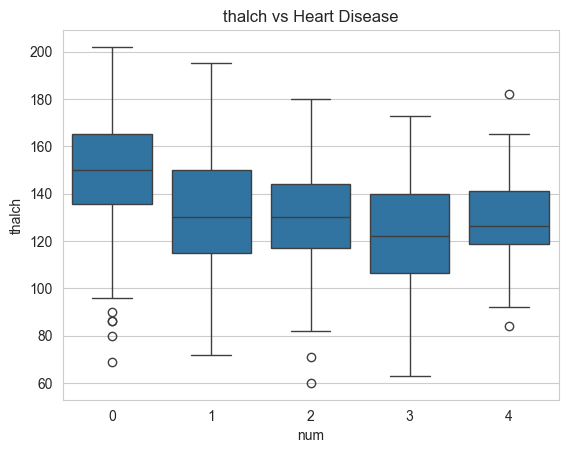

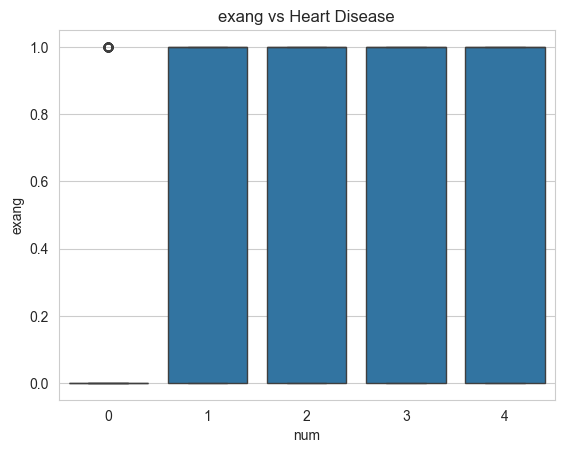

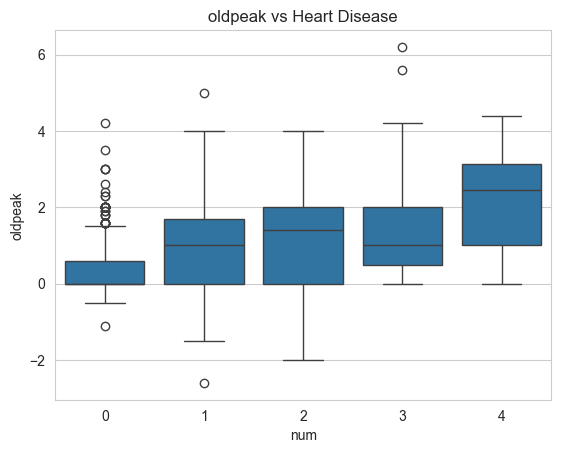

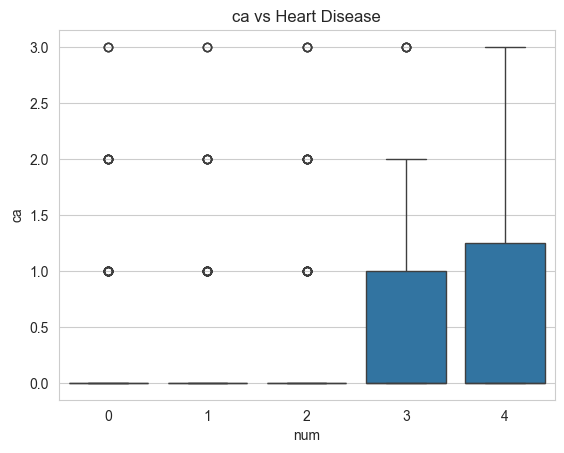

In [40]:
for col in num_cols:
    if col != 'num':
        sns.boxplot(x='num', y=col, data=df)
        plt.title(f'{col} vs Heart Disease')
        plt.show()


In [41]:
cat_cols = df.select_dtypes(include='object').columns


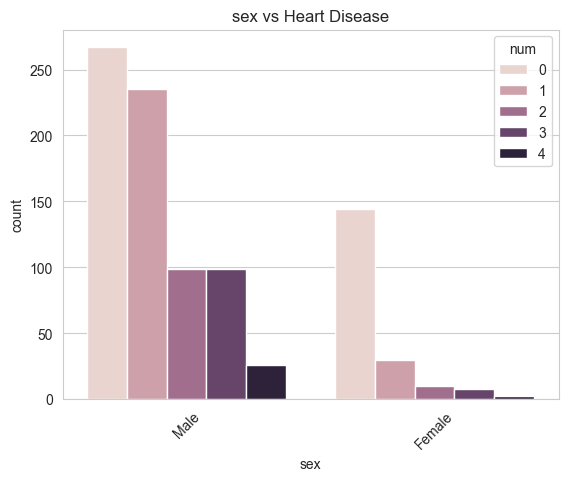

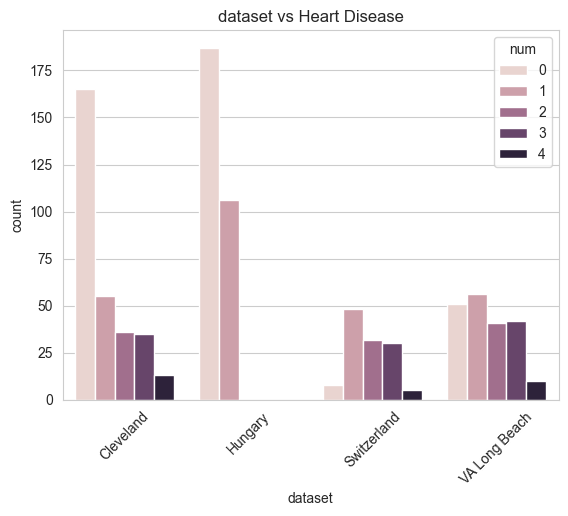

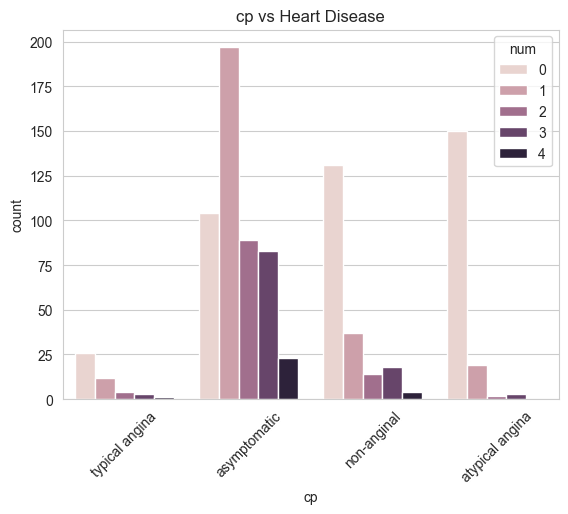

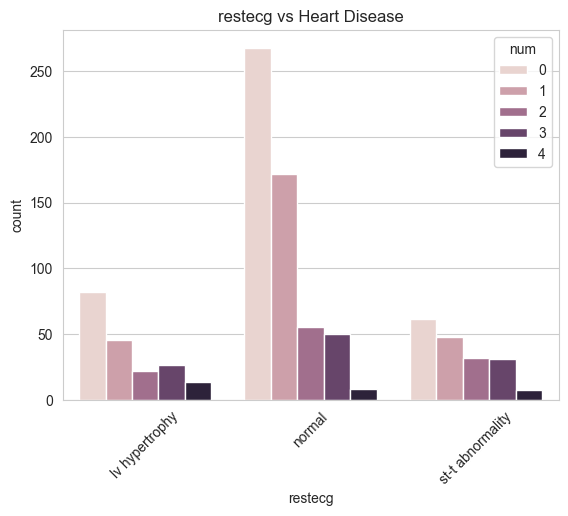

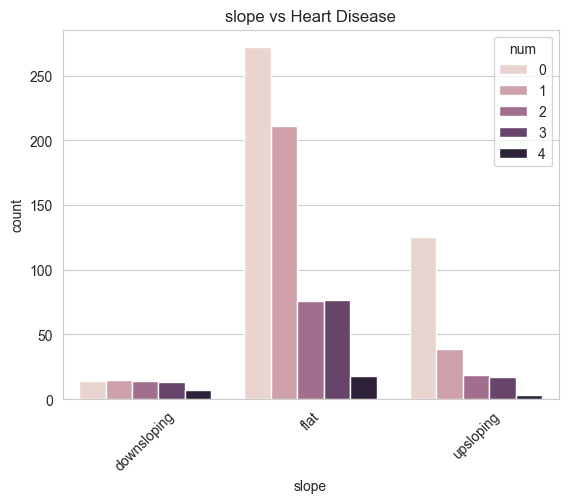

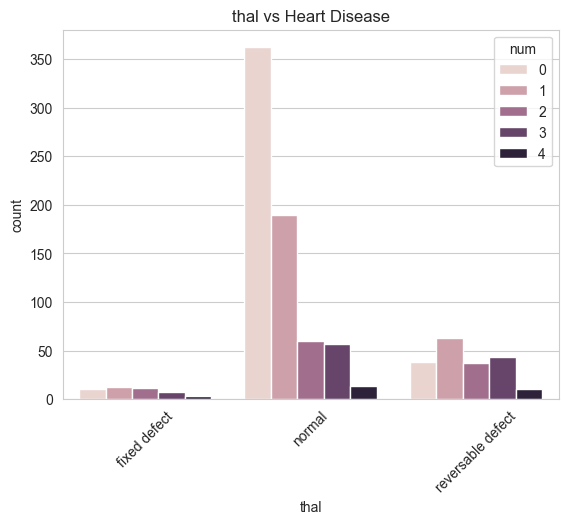

In [42]:
for col in cat_cols:
    sns.countplot(x=col, hue='num', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Heart Disease')
    plt.show()


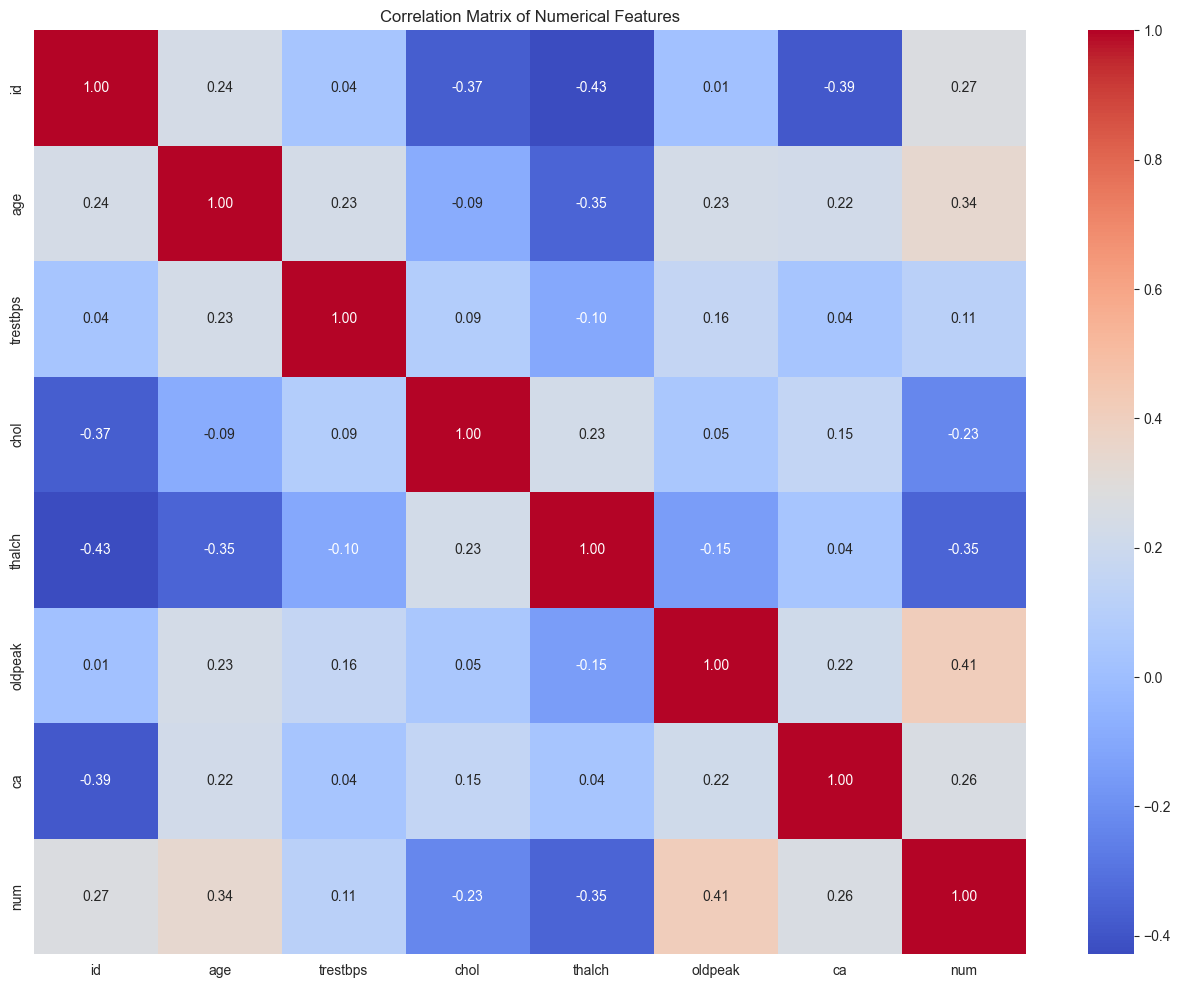

In [43]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


In [44]:
df = pd.get_dummies(df, drop_first=True)


In [45]:
df

,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,145.0,233.0,True,150.0,False,2.3,0.0,0,...,False,False,False,True,False,False,False,False,False,False
1,2,67,160.0,286.0,False,108.0,True,1.5,3.0,2,...,False,False,False,False,False,False,True,False,True,False
2,3,67,120.0,229.0,False,129.0,True,2.6,2.0,1,...,False,False,False,False,False,False,True,False,False,True
3,4,37,130.0,250.0,False,187.0,False,3.5,0.0,0,...,False,False,True,False,True,False,False,False,True,False
4,5,41,130.0,204.0,False,172.0,False,1.4,0.0,0,...,False,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,127.0,333.0,True,154.0,False,0.0,0.0,1,...,True,False,False,False,False,True,True,False,True,False
916,917,62,130.0,139.0,False,140.0,False,0.5,0.0,0,...,True,False,False,True,False,True,True,False,True,False
917,918,55,122.0,223.0,True,100.0,False,0.0,0.0,2,...,True,False,False,False,False,True,True,False,False,False
918,919,58,130.0,385.0,True,140.0,False,0.5,0.0,0,...,True,False,False,False,False,False,True,False,True,False


In [60]:
#Feature Scaling 
from sklearn.preprocessing import StandardScaler

X = df.drop('num', axis=1)
y = df['num']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [61]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier()
}


In [62]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print("Accuracy :", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds, average='weighted'))
    print("Recall   :", recall_score(y_test, preds, average='weighted'))
    print("F1 Score :", f1_score(y_test, preds, average='weighted'))

    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))



Logistic Regression
Accuracy : 0.5652173913043478
Precision: 0.6307841614906833
Recall   : 0.5652173913043478
F1 Score : 0.5897319644867863
Confusion Matrix:
 [[64 10  2  5  1]
 [ 5 27 10  6  5]
 [ 0  2  4 10  6]
 [ 1  6  4  5  5]
 [ 0  0  0  2  4]]

KNN
Accuracy : 0.5978260869565217
Precision: 0.5568101365983675
Recall   : 0.5978260869565217
F1 Score : 0.5750623089223019
Confusion Matrix:
 [[68 11  2  1  0]
 [12 35  5  1  0]
 [ 4  8  3  7  0]
 [ 3  8  6  4  0]
 [ 0  1  2  3  0]]

SVM
Accuracy : 0.5597826086956522
Precision: 0.6146197832533236
Recall   : 0.5597826086956522
F1 Score : 0.5830332705164445
Confusion Matrix:
 [[64 11  3  3  1]
 [ 4 27 12  8  2]
 [ 1  6  2  7  6]
 [ 1  5  6  8  1]
 [ 0  0  3  1  2]]

Decision Tree
Accuracy : 0.5869565217391305
Precision: 0.6129764292104356
Recall   : 0.5869565217391305
F1 Score : 0.5976727557848541
Confusion Matrix:
 [[60  9  6  5  2]
 [ 7 30  8  6  2]
 [ 3  5 10  4  0]
 [ 3  6  4  6  2]
 [ 0  2  1  1  2]]

Random Forest
Accuracy : 0.641304

/Users/vimleshgupta/Day-4/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy : 0.6521739130434783
Precision: 0.63646761404134
Recall   : 0.6521739130434783
F1 Score : 0.6429030056488352
Confusion Matrix:
 [[71  5  5  1  0]
 [ 5 37  6  4  1]
 [ 2  7  9  4  0]
 [ 2 11  3  3  2]
 [ 0  1  1  4  0]]


In [52]:
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.61      0.70      0.65        53
           2       0.38      0.41      0.39        22
           3       0.19      0.14      0.16        21
           4       0.00      0.00      0.00         6

    accuracy                           0.65       184
   macro avg       0.41      0.42      0.42       184
weighted avg       0.64      0.65      0.64       184



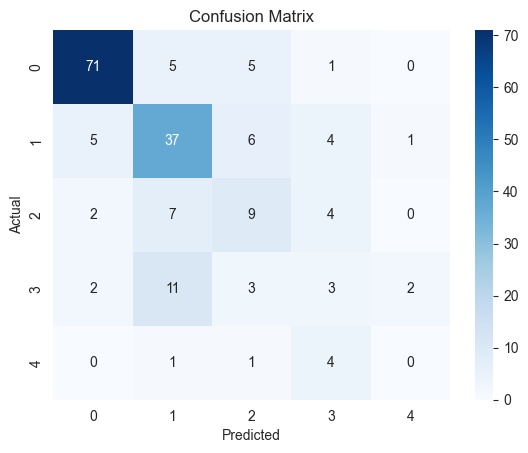

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
